# DSAI 3204 – IoT Application Development
## Project Part B: Time Series Analysis & Forecasting
**Group 10** | Sadiq, Syed Umar (60302575) & Zain, Mohamad (60306080)

## Step 1: Install Required Packages

In [61]:
# Install any packages not available in the default environment
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

## Step 2: Import Libraries

In [62]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Machine learning and evaluation
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 3: Load the Dataset

In [63]:
# loading the IoT telemetry dataset given in  D2L
# Dataset contains readings from 3 IoT devices over ~8 days (July 12-20, 2020)
df_raw = pd.read_csv('iot_telemetry_data.csv')

# Converting Unix timestamp (seconds) to datetime
df_raw['ts'] = pd.to_datetime(df_raw['ts'].astype(float), unit='s')

print('Raw dataset shape:', df_raw.shape)
print('\nColumn names:', df_raw.columns.tolist())
print('\nDate range:', df_raw['ts'].min(), 'to', df_raw['ts'].max())
print('\nDevices found:', df_raw['device'].unique())
df_raw.head()

Raw dataset shape: (405184, 9)

Column names: ['ts', 'device', 'co', 'humidity', 'light', 'lpg', 'motion', 'smoke', 'temp']

Date range: 2020-07-12 00:01:34.385974646 to 2020-07-20 00:03:37.264312506

Devices found: ['b8:27:eb:bf:9d:51' '00:0f:00:70:91:0a' '1c:bf:ce:15:ec:4d']


,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,2020-07-12 00:01:34.385974646,b8:27:eb:bf:9d:51,0.004956,51.000000,False,0.007651,False,0.020411,22.700000
1,2020-07-12 00:01:34.735567570,00:0f:00:70:91:0a,0.002840,76.000000,False,0.005114,False,0.013275,19.700001
2,2020-07-12 00:01:38.073572874,b8:27:eb:bf:9d:51,0.004976,50.900000,False,0.007673,False,0.020475,22.600000
3,2020-07-12 00:01:39.589145899,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000
4,2020-07-12 00:01:41.761234999,b8:27:eb:bf:9d:51,0.004967,50.900000,False,0.007664,False,0.020448,22.600000


## Step 4: Data Preprocessing
### 4.1 Filter to One Device and Select Key Sensors

In [64]:
# Selecting one device to keep data consistent 
TARGET_DEVICE = 'b8:27:eb:bf:9d:51'
df = df_raw[df_raw['device'] == TARGET_DEVICE].copy()

# Selecting important sensor columns
SENSORS = ['temp', 'co', 'humidity', 'smoke']
df = df[['ts'] + SENSORS].sort_values('ts').reset_index(drop=True)

print(f'Rows after device filter: {len(df)}')
print(f'\nSensor summary:')
df[SENSORS].describe().round(4)

Rows after device filter: 187451

Sensor summary:


,temp,co,humidity,smoke
count,187451.0000,187451.0000,187451.0000,187451.0000
mean,22.2800,0.0056,50.8141,0.0223
std,0.4819,0.0006,1.8889,0.0017
min,21.0000,0.0046,45.1000,0.0194
25%,21.9000,0.0051,49.6000,0.0208
50%,22.3000,0.0054,50.9000,0.0219
75%,22.6000,0.0060,52.1000,0.0236
max,24.1000,0.0080,63.3000,0.0294


### 4.2 Check for Missing Values

Missing values per column:
temp        0
co          0
humidity    0
smoke       0
dtype: int64


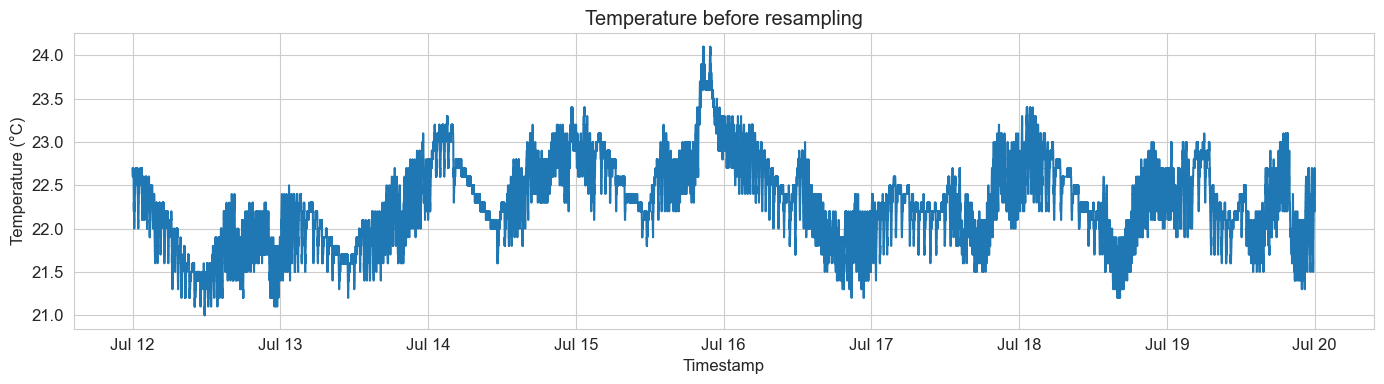

In [67]:
# Check missing values before resampling
print('Missing values per column:')
print(df[SENSORS].isnull().sum())

# Visualise the raw temperature time series before any processing
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['ts'], df['temp'])
ax.set_title('''Temperature before resampling''')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

### 4.3 Resample to 5-Minute Intervals

In [68]:
# resampling to 5 minutes to make data uniform
# This reduces the 187K raw rows to 2300 evenly-spaced intervals
df_res = (
    df.set_index('ts')[SENSORS]
    .resample('5min')
    .mean()
    .interpolate(method='time')   # Filling any empty 5-min windows through linear interpolation
    .dropna()
    .reset_index()
)

print(f'Resampled rows: {len(df_res)}')
print(df_res.head())

Resampled rows: 2305
                   ts       temp        co   humidity     smoke
0 2020-07-12 00:00:00  22.628571  0.004961  50.926786  0.020428
1 2020-07-12 00:05:00  22.641975  0.004987  50.903704  0.020511
2 2020-07-12 00:10:00  22.262195  0.004990  49.045122  0.020520
3 2020-07-12 00:15:00  22.117284  0.005013  50.366667  0.020592
4 2020-07-12 00:20:00  22.401220  0.005055  50.906098  0.020726


### 4.4 Outlier Detection and Removal

In [69]:
# removing outliers using IQR method

def remove_outliers_iqr(df, columns, factor=3.0):

    mask = pd.Series([True] * len(df))
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        col_mask = df[col].between(lower, upper)
        removed = (~col_mask).sum()
        if removed > 0:
            print(f'  [{col}] Removed {removed} outliers (bounds: {lower:.4f} – {upper:.4f})')
        mask = mask & col_mask
    return df[mask].reset_index(drop=True)

print('Outlier removal report:')
df_clean = remove_outliers_iqr(df_res, SENSORS)
print(f'\nRows before: {len(df_res)}, after: {len(df_clean)} (removed {len(df_res)-len(df_clean)})')

Outlier removal report:
  [humidity] Removed 2 outliers (bounds: 42.8889 – 58.8160)

Rows before: 2305, after: 2303 (removed 2)


## Step 5: Time Series Analysis
### 5.1 Sensor Overview

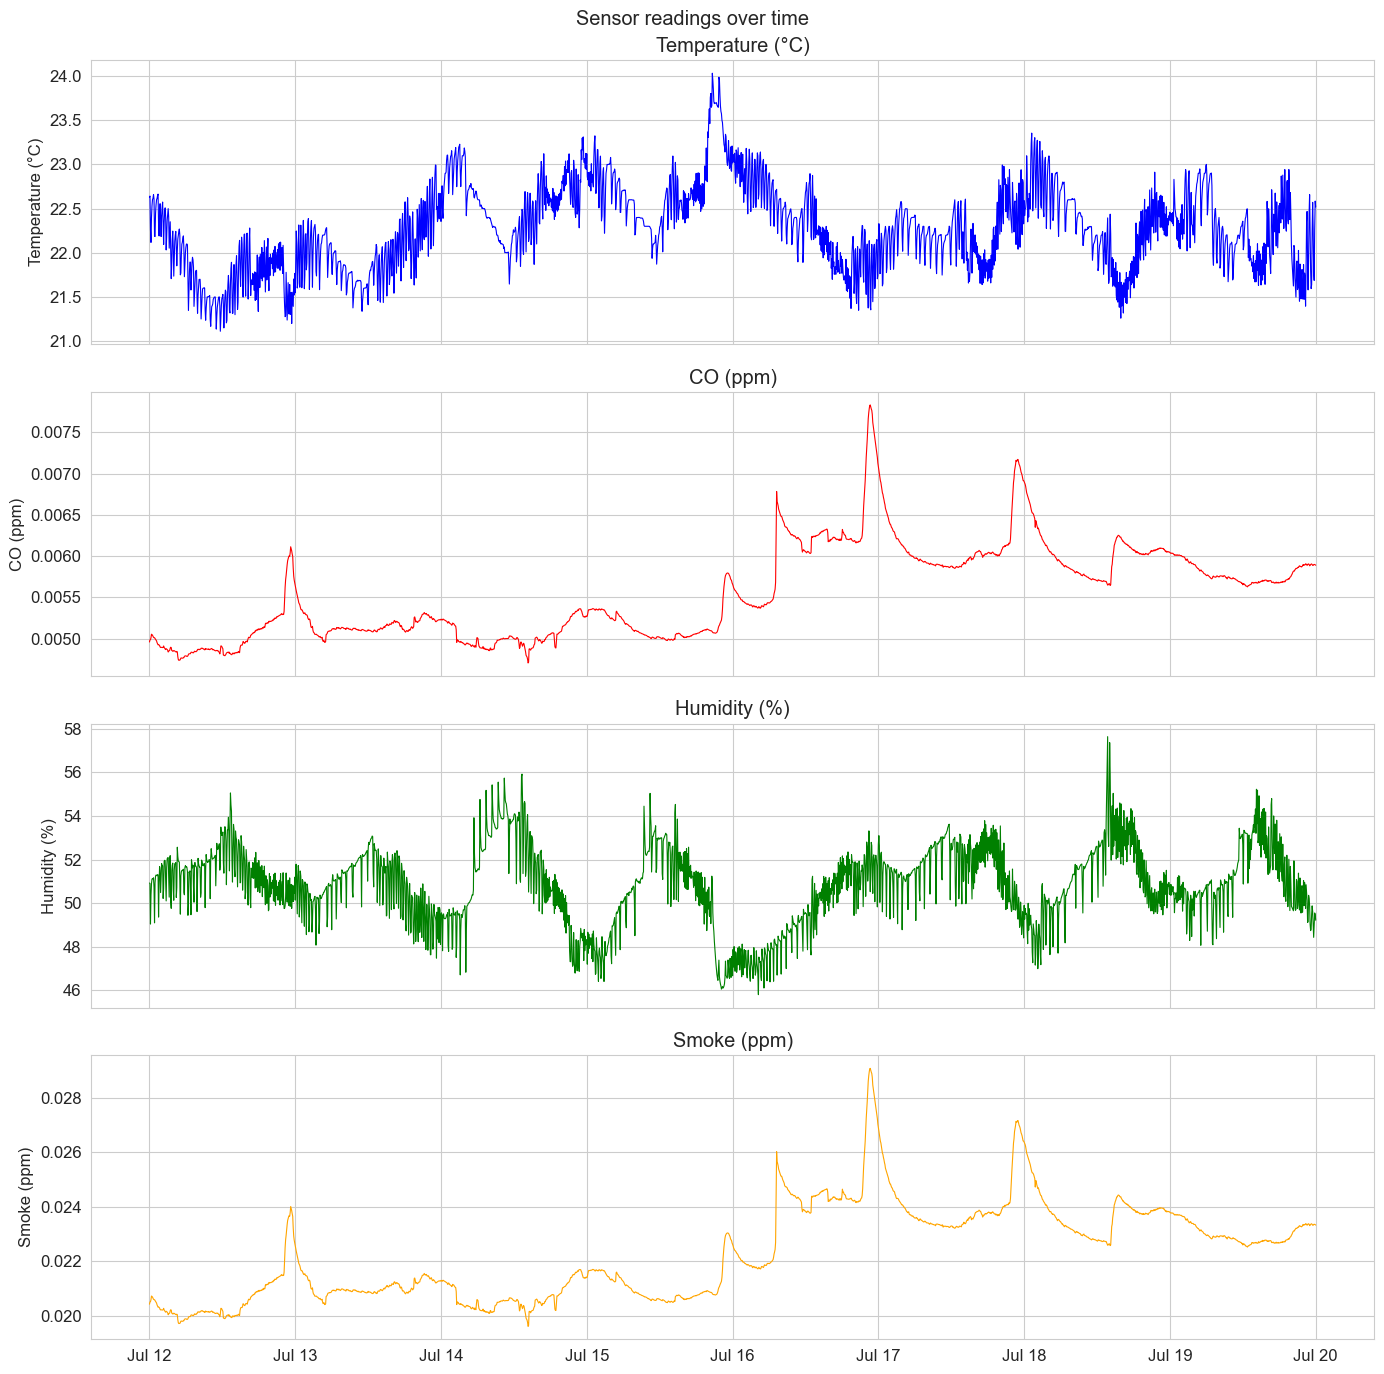

In [71]:
# Ploting all four sensors over the full 8-day period to inspect the overall trends
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
colors = ['blue', 'red', 'green', 'orange']
labels = ['Temperature (°C)', 'CO (ppm)', 'Humidity (%)', 'Smoke (ppm)']

for ax, col, color, label in zip(axes, SENSORS, colors, labels):
    ax.plot(df_clean['ts'], df_clean[col], color=color, linewidth=0.8)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('Sensor readings over time')
plt.tight_layout()
plt.show()

### 5.2 Daily Temperature Pattern (Diurnal Cycle)

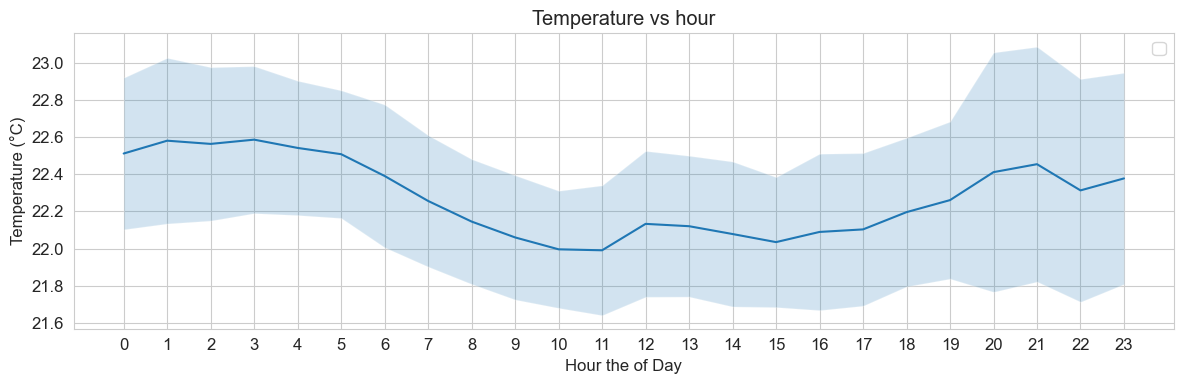

In [72]:
#Checking the temperature pattern on an hourly basis to observe the daily temperature trend.
df_clean['hour'] = df_clean['ts'].dt.hour

# Computing the mean temperature per hour across all days
hourly_mean = df_clean.groupby('hour')['temp'].mean()
hourly_std  = df_clean.groupby('hour')['temp'].std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_mean.index, hourly_mean.values)
ax.fill_between(hourly_mean.index,
                hourly_mean - hourly_std,
                hourly_mean + hourly_std,
                alpha=0.2)
ax.set_title('Temperature vs hour')
ax.set_xlabel('Hour the of Day')
ax.set_ylabel('Temperature (°C)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()



### 5.3 Correlation Between Sensors

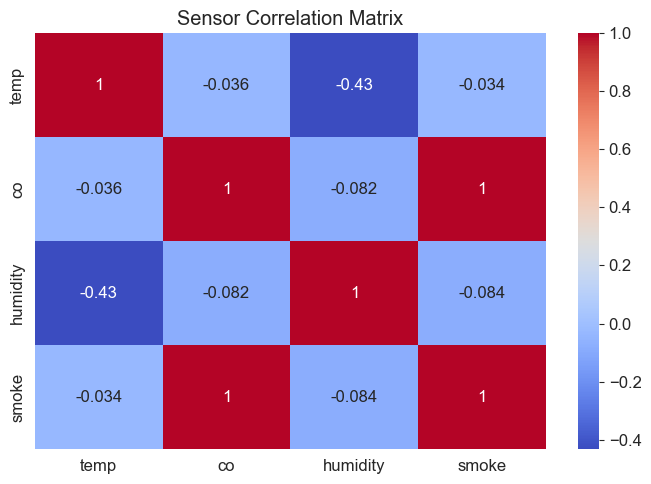

CO and smoke are highly correlated
Temperature shows moderate correlation with CO and smoke.


In [83]:
# Computing and visualizing correlation matrix to understand sensor inter-relationships
corr = df_clean[SENSORS].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

print('CO and smoke are highly correlated')
print('Temperature shows moderate correlation with CO and smoke.')

### 5.4 7-Day Rolling Mean (Trend Detection)

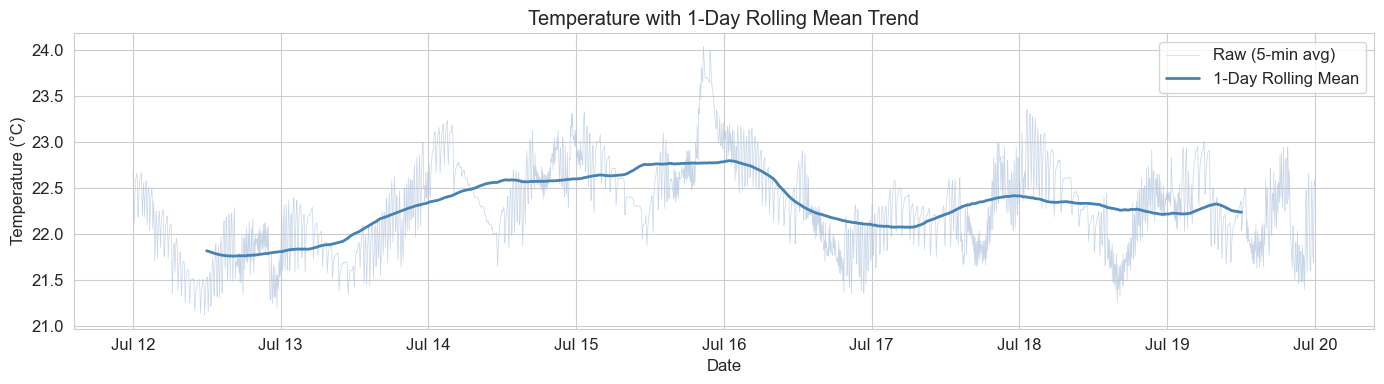

In [74]:
# A rolling mean over 288 periods (= 1 day of 5-min intervals) highlights the
# underlying temperature trend, smoothing out short-term fluctuations.
window = 288  # 288 × 5 min = 1 day
df_clean['temp_rolling'] = df_clean['temp'].rolling(window, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_clean['ts'], df_clean['temp'], color='lightsteelblue', linewidth=0.5, label='Raw (5-min avg)', alpha=0.7)
ax.plot(df_clean['ts'], df_clean['temp_rolling'], color='steelblue', linewidth=2, label='1-Day Rolling Mean')
ax.set_title('Temperature with 1-Day Rolling Mean Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Feature Engineering for ML Model

In [75]:
# Creating time-based and lag features so the model can learn temporal patterns.
# These features are computed from historical values only
# so there is no data leakage into the future.

df_feat = df_clean[['ts', 'temp', 'co', 'humidity', 'smoke']].copy()

# ── Time-based features ──
df_feat['hour']       = df_feat['ts'].dt.hour          # Hour of day (0-23)
# df_feat['dayofweek']  = df_feat['ts'].dt.dayofweek     # Day of week (0=Monday)
df_feat['minute']     = df_feat['ts'].dt.minute        # Minute within hour

# Cyclic encoding for hour (prevents 23→0 discontinuity)
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)

# Lag features (past temperature values) 
df_feat['lag_1'] = df_feat['temp'].shift(1)    # 5 min ago
df_feat['lag_2'] = df_feat['temp'].shift(2)    # 10 min ago
df_feat['lag_6'] = df_feat['temp'].shift(6)    # 30 min ago
df_feat['lag_12'] = df_feat['temp'].shift(12)   # 1 hour ago

# Rolling statistics (recent trend & volatility)
df_feat['roll_mean_6']  = df_feat['temp'].shift(1).rolling(6).mean()   # 30-min rolling mean
# df_feat['roll_mean_12'] = df_feat['temp'].shift(1).rolling(12).mean()  # 1-hr rolling mean

# Drop rows with NaN introduced by lag/rolling features
df_feat = df_feat.dropna().reset_index(drop=True)

print(f'Feature matrix shape: {df_feat.shape}')
print(f'\nFeatures created:\n{df_feat.columns.tolist()}')

Feature matrix shape: (2291, 14)

Features created:
['ts', 'temp', 'co', 'humidity', 'smoke', 'hour', 'minute', 'hour_sin', 'hour_cos', 'lag_1', 'lag_2', 'lag_6', 'lag_12', 'roll_mean_6']


## Step 7: Train/Test Split

In [76]:
# Define features (X) and target (y)
FEATURE_COLS = [
    'hour_sin', 'hour_cos', 'minute',
     # 'hour_sin', 'hour_cos', 'dayofweek', 'minute',

    'co', 'humidity', 'smoke',
    'lag_1', 'lag_2', 'lag_6', 'lag_12', 
        # 'lag_1', 'lag_2', 'lag_6', 'lag_12', 'lag_288',

    'roll_mean_6'
        # 'roll_mean_6', 'roll_std_6', 'roll_mean_12'

]
TARGET_COL = 'temp'

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]

# Doing a 80/20 chronological split 
# Shuffling would cause data leakage 
SPLIT = int(len(df_feat) * 0.8)
X_train, X_test = X.iloc[:SPLIT], X.iloc[SPLIT:]
y_train, y_test = y.iloc[:SPLIT], y.iloc[SPLIT:]
ts_test = df_feat['ts'].iloc[SPLIT:]

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'\nTraining period  : {df_feat["ts"].iloc[0].date()} → {df_feat["ts"].iloc[SPLIT-1].date()}')
print(f'Testing period   : {df_feat["ts"].iloc[SPLIT].date()} → {df_feat["ts"].iloc[-1].date()}')

Training samples : 1832
Test samples     : 459

Training period  : 2020-07-12 → 2020-07-18
Testing period   : 2020-07-18 → 2020-07-20


## Step 8: Model Training – XGBoost Regressor

**Model Choice: XGBoost (Extreme Gradient Boosting)**

XGBoost was chosen for the following reasons:
- Handles non-linear relationships between time features and temperature naturally
- Robust to outliers and noisy sensor data
- Supports custom lag/rolling features (unlike ARIMA/LSTM which have stricter input requirements)
- Fast training and strong performance on tabular time series data
- Built-in feature importance allows interpretability

In [77]:
# Train the XGBoost regressor with tuned hyperparameters
model = XGBRegressor(
    n_estimators=200,        # Number of boosting rounds
    learning_rate=0.05,      # Step size shrinkage to prevent overfitting
    max_depth=6,             # Maximum tree depth
    random_state=42,
)


model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('Model training complete.')

Model training complete.


## Step 9: Performance Evaluation

In [78]:
# Generate predictions on the held-out test set
y_pred = model.predict(X_test)

# ── Compute RMSE and MAE ──
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print('       MODEL PERFORMANCE METRICS')

print(f'  RMSE (Root Mean Square Error) : {rmse:.4f} °C')
print(f'  MAE  (Mean Absolute Error)    : {mae:.4f} °C')

print(f'\nInterpretation:')
print(f'  On average, predictions deviate by ±{mae:.2f}°C from actual values.')
print(f'  RMSE penalises larger errors more strongly; {rmse:.2f}°C indicates good fit.')

       MODEL PERFORMANCE METRICS
  RMSE (Root Mean Square Error) : 0.2183 °C
  MAE  (Mean Absolute Error)    : 0.1676 °C

Interpretation:
  On average, predictions deviate by ±0.17°C from actual values.
  RMSE penalises larger errors more strongly; 0.22°C indicates good fit.


### 9.1 Actual vs Predicted Plot

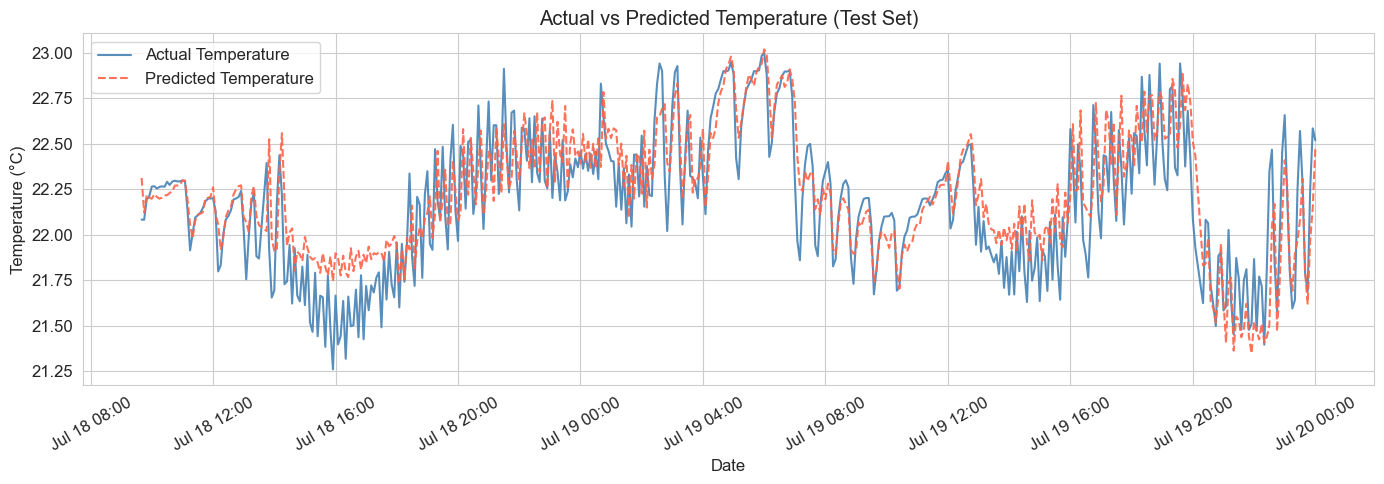

In [79]:
# Visualise how closely the model's predictions follow actual sensor readings
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_test.values, y_test.values, color='steelblue', linewidth=1.5, label='Actual Temperature', alpha=0.9)
ax.plot(ts_test.values, y_pred,        color='tomato',    linewidth=1.5, label='Predicted Temperature', alpha=0.9, linestyle='--')
ax.set_title('Actual vs Predicted Temperature (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 9.2 Residual Analysis

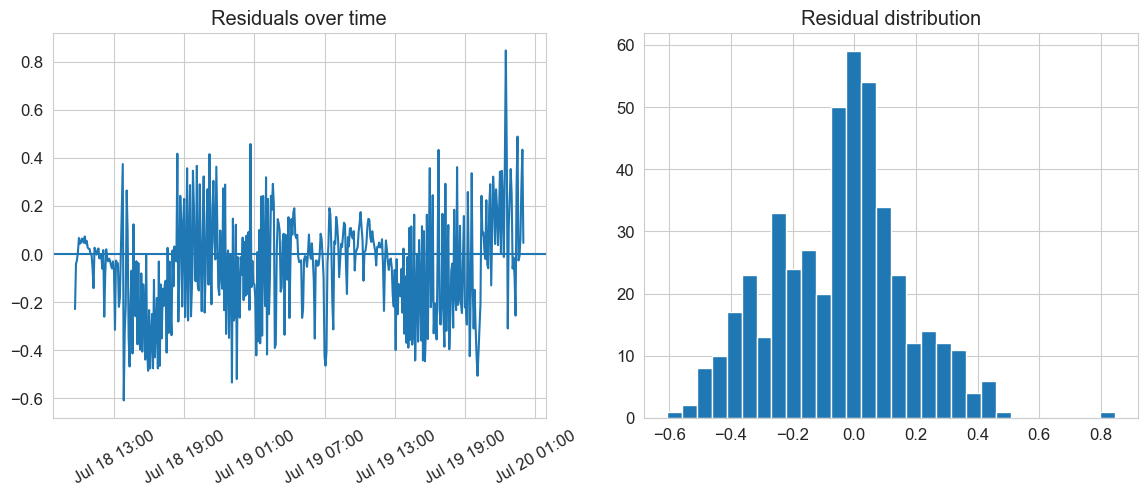

In [80]:
# calculate residuals
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2)

# residuals over time
axes[0].plot(ts_test.values, residuals)

axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))

plt.setp(axes[0].get_xticklabels(), rotation=30)

axes[0].axhline(0)
axes[0].set_title('Residuals over time')

# distribution of residuals
axes[1].hist(residuals, bins=30)
axes[1].set_title('Residual distribution')

plt.show()

### 9.3 Feature Importance

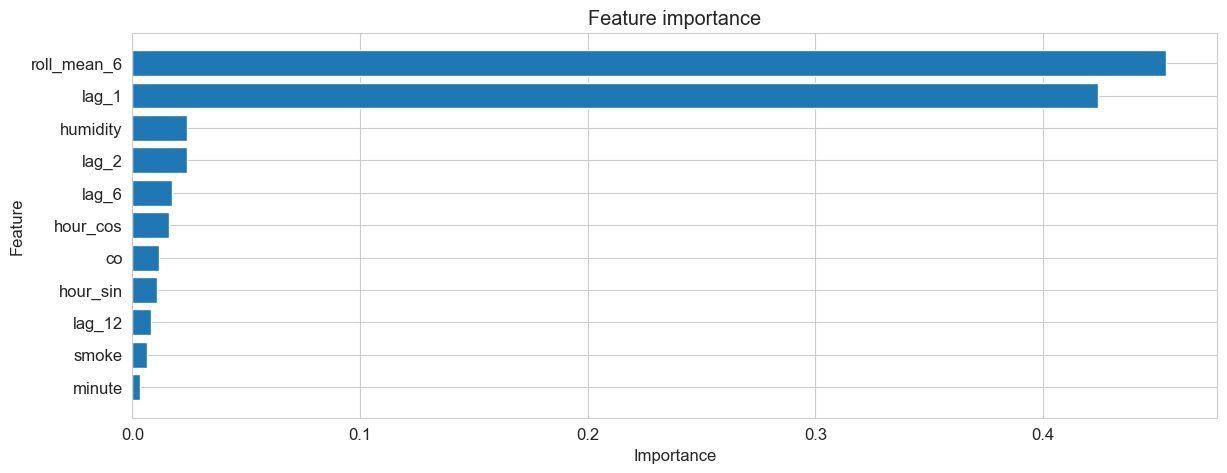

In [81]:
# check which features are more important
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance')

fig, ax = plt.subplots()

ax.barh(importance_df['feature'], importance_df['importance'])

ax.set_title('Feature importance')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')

plt.show()

## Step 10: Summary

In [82]:
print('Project Part B Summary\n')

print('Dataset : IoT data (8 days)')
print('Device used : b8:27:eb:bf:9d:51')
print('Target : Temperature')

print('Total rows after processing :', len(df_feat))
print('Train/Test split : 80/20')

print('Model used : XGBoost')

print('RMSE =', round(rmse, 4))
print('MAE =', round(mae, 4))

print('\nObservations:')
print('- Temperature shows a daily pattern')
print('- CO and smoke are closely related')
print('- Previous values (lag features) help most in prediction')

Project Part B Summary

Dataset : IoT data (8 days)
Device used : b8:27:eb:bf:9d:51
Target : Temperature
Total rows after processing : 2291
Train/Test split : 80/20
Model used : XGBoost
RMSE = 0.2183
MAE = 0.1676

Observations:
- Temperature shows a daily pattern
- CO and smoke are closely related
- Previous values (lag features) help most in prediction
